# Importing everything and loading files

In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
import os
import re
from utils import *
from sklearn.linear_model import LinearRegression
import psana

In [2]:
###############################################
runNumbers = [300]  # enter the run numbers to be loaded
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = [#'CXI-DG2-BMMON-WF/ROI_rebin_data',
                   'CXI-DG2-BMMON-WF/ROI_area',
                    'jungfrau4M/azav_mask0_azav', # Unfiltered
                   'jungfrau4M/azav_mask1_azav', # Filtered
                   'ipm_dg2/sum',
                   'ipm_dg2/peaks',
                   'ipm_dg2/xpos',
                   'ipm_dg2/ypos',
                    #'ipm_dg3/sum',
                   #'ipm_hfx_dg2/sum',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  #'CXI-DG2-BMMON-WF/cxi_dg2_bmmon_wf_rebin_data',
                  'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj',
                  'lightStatus/laser',
                  #'dg2_traces'
                   'ipm_dg2/sum',
                    'ipm_hfx_dg2/sum'
                  ]

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq',
                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/cmask']
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

# Filtered Data
azavFiltered = np.squeeze(data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbinFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bins 
qbinsFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins
userMaskFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool) # User mask for this region
qbinSizeFiltered = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq'])
# Unfiltered Data
azav = np.squeeze(data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin'] # q bin-size
q = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins'] # q bins
userMask = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool) # User mask for this region
qbinSize = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq'])
# Other Data
matrix_q = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q'].reshape(8,512,1024) # Q values J4M shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi'].reshape(8,512,1024) # phi valyes J4M shaped
xrayOn = data['evr/code_137'].astype(bool)  # xray on events
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events
laserOn = data['lightStatus/laser'].astype(bool)  # xray on events
jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 

cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = data['run_indicator'] # run indicator for each shot
# dg3 = data['ipm_dg3/sum']    # downstream diode x-ray intensity
# pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = data['ebeam/photon_energy']    # x-ray energy energy in eV|
#dg2Trace = data['CXI-DG2-BMMON-WF/cxi_dg2_bmmon_wf_rebin_data']
numPhotons = data['jungfrau4M/Full_thres_sum']
spec = data['feeBld/hproj'] # Shot to shot spectrometer
#dg2traces = data['dg2_traces'][()][:,:,::8] # Dg2 traces, downsampled by a factor of 8
#dg2Sum = data['ipm_dg2/sum']
#dg2Sum = np.sum(np.sum(data['CXI-DG2-BMMON-WF/ROI_rebin_data'],axis=1),axis=1)
dg2traces = data['CXI-DG2-BMMON-WF/ROI_area'] # Downsampling by a factor of 8, makes the refitting much better in the long run
ipm = data['ipm_dg2/sum']
ipmpeaks = data['ipm_dg2/peaks']
xpos = data['ipm_dg2/xpos']
ypos = data['ipm_dg2/ypos']
hfxSum = data['ipm_hfx_dg2/sum']
#dg2tracesFull = data['CXI-DG2-BMMON-WF/ROI_rebin_data']
del data

# For some reason we need to offet the data by one. Will this be a problem in later experiments?
# spec = spec[0:-2];
# azavFiltered = azavFiltered[1:-1];
# azav = azav[1:-1];
# xrayOn = xrayOn[1:-1];
# xrayOn2 = xrayOn2[1:-1];
# laserOn = laserOn[1:-1];
# dg2traces = dg2traces[1:-1];
# ipm = ipm[1:-1]
#dg2tracesFull = dg2tracesFull[1:-1];
#dg2Sum = dg2Sum[1:-1];

Loading: /sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/cxil1037623_Run0300.h5
Loaded Data


In [8]:
###############################################
runNumbers = [105]  # enter the run numbers to be loaded
#folder = '/sdf/data/lcls/ds/cxi/cxil1006021/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
#folder = '/sdf/data/lcls/ds/cxi/cxil1006021/results/lhuang3/dg2/'
#folder = '/sdf/data/lcls/ds/cxi/cxil1038423/hdf5/smalldata/'
folder = '/sdf/data/lcls/ds/cxi/cxilx6520/hdf5/smalldata/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = ['jungfrau4M/azav_azav',
                   'ipm_dg2/sum',
                   'ipm_dg2/xpos',
                   'ipm_dg2/ypos',
                   'ipm_dg2/peaks',
                   #'dg2_traces',
                   'CXI-DG2-BMMON-WF/ROI_area',
                    #'ipm_dg3/sum',
                   #'ipm_hfx_dg2/sum',
                   #'alvium_u1/laser_com',
                   #'alvium_u1/laser_sum',
                   #'Acqiris/FastTiming_area',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/laser',
                   'lightStatus/xray']

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav__azav_q',
                'UserDataCfg/jungfrau4M/azav__azav_qbin',
                'UserDataCfg/jungfrau4M/azav__azav_qbins',
                 'UserDataCfg/jungfrau4M/azav__azav_idxq',
                 'UserDataCfg/jungfrau4M/x',
                 'UserDataCfg/jungfrau4M/y',
                 'UserDataCfg/jungfrau4M/z',
                 'UserDataCfg/jungfrau4M/azav__azav_matrix_q',
                 'UserDataCfg/jungfrau4M/azav__azav_matrix_phi',
                #'UserDataCfg/jungfrau4M/cmask',
                # 'UserDataCfg/jungfrau4M/Full_thres__Full_thres_thresADU',
                # 'UserDataCfg/jungfrau4M/Full_thres__Full_thres_bound',
                'UserDataCfg/jungfrau4M/common_mode_pars']
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=True)  # this is the function to load the data with defined keys

azav = np.squeeze(data['jungfrau4M/azav_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = data['UserDataCfg/jungfrau4M/azav__azav_qbin'] # q bin-size
q = data['UserDataCfg/jungfrau4M/azav__azav_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav__azav_qbins'] # q bins
qbinSize = np.bincount(data['UserDataCfg/jungfrau4M/azav__azav_idxq'])
matrix_q = data['UserDataCfg/jungfrau4M/azav__azav_matrix_q'].reshape(8,512,1024)  # q matrix Jungfrau shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav__azav_matrix_phi'].reshape(8,512,1024) # phi for anisotropic data
laserOn = data['evr/code_183'].astype(bool)  # laser on events
xrayOn = data['evr/code_137'].astype(bool)  # xray on events
laserOn2 = data['lightStatus/laser'].astype(bool)  # laser on events 
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events
jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 

#cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = data['run_indicator'] # run indicator for each shot
# UV_com = data['alvium_u1/laser_com']  # center of mass for laser (pump) pointing
# UV_sum = data['alvium_u1/laser_sum']   # intensity sum for laser (pump) pointing
# Acqiris_FastTiming = data['Acqiris/FastTiming_area']  # diode signal for laser after interaction
# Acqiris_Laser = data['Acqiris/Laser_area'] # diode signal for laser before interaction
ipm = data['ipm_dg2/sum']   # upstream diode x-ray intensity
#dg2traces = data['dg2_traces']
dg2traces = data['CXI-DG2-BMMON-WF/ROI_area']
ipmpeaks = data['ipm_dg2/peaks']
xpos = data['ipm_dg2/xpos']
ypos = data['ipm_dg2/ypos']
# dg3 = data['ipm_dg3/sum']    # downstream diode x-ray intensity
# pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = data['ebeam/photon_energy']    # x-ray energy energy in eV

Loading: /sdf/data/lcls/ds/cxi/cxilx6520/hdf5/smalldata/cxilx6520_Run0105.h5
Sums/jungfrau4M_calib (1,)
UserDataCfg/EOrbits/detname (1,)
UserDataCfg/EOrbits/name (1,)
UserDataCfg/damage/detAlias (13,)
UserDataCfg/damage/detNames (13,)
UserDataCfg/damage/name (1,)
UserDataCfg/epicsAll/PVlist (463,)
UserDataCfg/epicsAll/PVlist_PV (463,)
UserDataCfg/epicsAll/detname (1,)
UserDataCfg/epicsAll/name (1,)
UserDataCfg/ipm_dg2/detname (1,)
UserDataCfg/ipm_dg2/name (1,)
UserDataCfg/ipm_dg2/savePos (1,)
UserDataCfg/ipm_dg3/detname (1,)
UserDataCfg/ipm_dg3/name (1,)
UserDataCfg/ipm_dg3/savePos (1,)
UserDataCfg/jungfrau4M/applyMask (1,)
UserDataCfg/jungfrau4M/azav__azav_ADU_per_photon (1,)
UserDataCfg/jungfrau4M/azav__azav_Cake_Npixel (1331,)
UserDataCfg/jungfrau4M/azav__azav_Cake_idxs (3854194,)
UserDataCfg/jungfrau4M/azav__azav_Cake_norm (1, 1331)
UserDataCfg/jungfrau4M/azav__azav_Pplane (1,)
UserDataCfg/jungfrau4M/azav__azav_center (2,)
UserDataCfg/jungfrau4M/azav__azav_correction (3854194,)
Use

KeyError: 'jungfrau4M/azav_azav'

### Filtering out the data from bad j4m shots and no xrays

In [3]:
azav=np.nanmean(azav,axis=1)

In [3]:
azav.shape

(51011, 76)

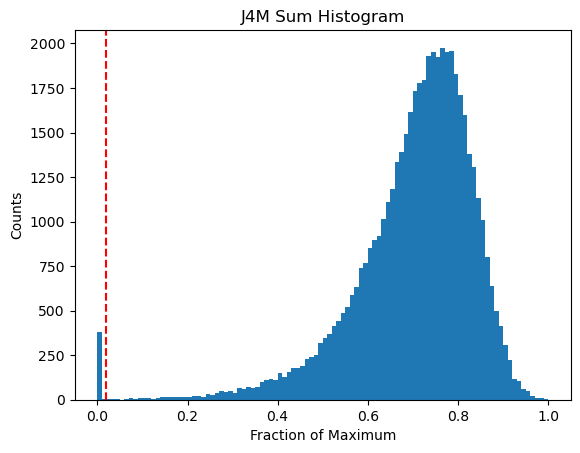

In [4]:
##########
integration_cutoff_hb = 0.2
integration_cutoff_lb = 0.05
scattering_cutoff = 0.02
##########
scattered_xrays = np.sum(azav,axis=-1)
#scattered_xraysFiltered = np.sum(azavFiltered*qbinSizeFiltered,axis=-1)

plt.hist(scattered_xrays/scattered_xrays.max(),bins=100)
plt.axvline(scattering_cutoff,color='r',linestyle='--')
plt.title('J4M Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()
# Doing the actual filtering
goodIdx = (xrayOn2) & (scattered_xrays/scattered_xrays.max()>scattering_cutoff) & (~laserOn) & (~np.isnan(scattered_xrays)) & (~np.isnan(ipm))
#specGood = spec[goodIdx]
dg2Good = dg2traces[goodIdx]
J4MSum = scattered_xrays[goodIdx]
ipmGood = ipm[goodIdx]
#ipmpeaksGood = ipmpeaks[goodIdx]
xposGood = xpos[goodIdx]
yposGood = ypos[goodIdx]
#hfxSumGood = hfxSum[goodIdx]

In [21]:
pwd

'/sdf/home/d/davidjr/CXI/L-10376'

In [11]:
# Exporting one of the traces
data = np.load('DG2Trace.npz')
data['arr_0'].shape

(8, 4096)

### Taking a look at the ipmdg2sum correlation

[4.06312473e-03 5.79928718e+01]


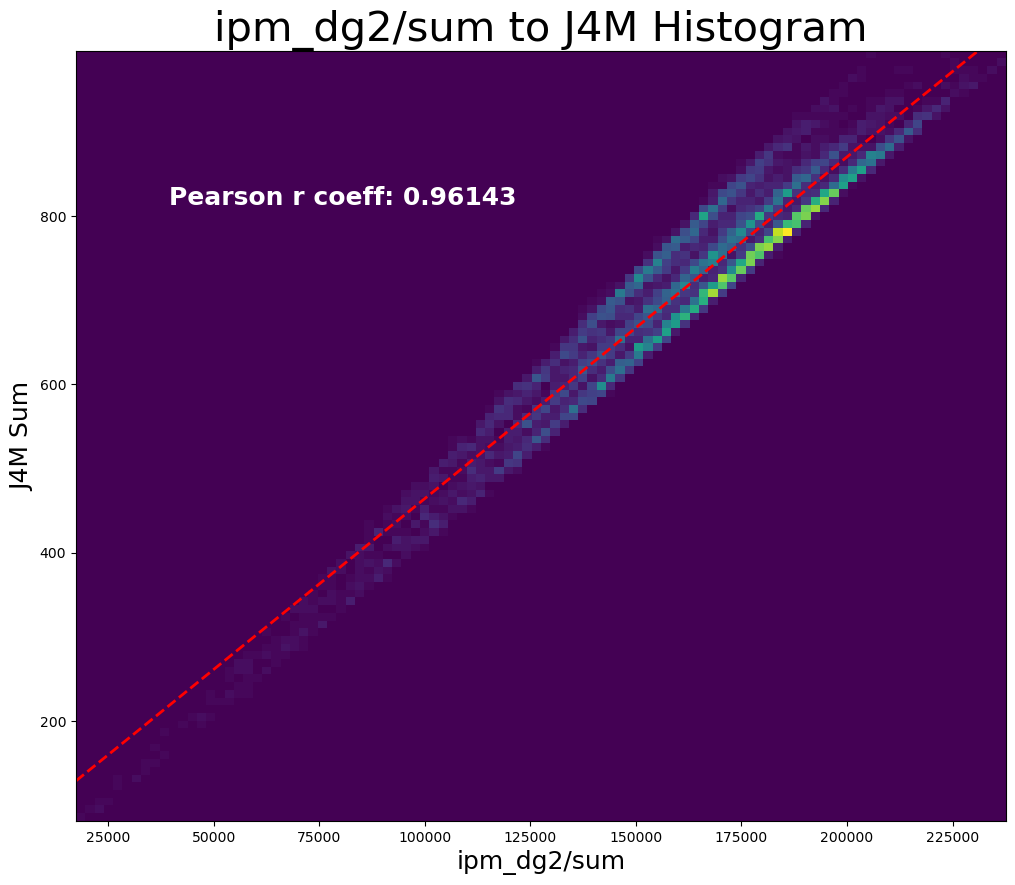

In [5]:
plt.figure(figsize=[12,10])

poly_coeffs = np.polyfit(ipmGood, J4MSum, 1)
print(poly_coeffs)
# Generate fit curve
x_fit = np.linspace(np.min(ipmGood), np.max(ipmGood), 100)
y_fit = np.polyval(poly_coeffs, x_fit)

# Overlay the fit curve
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear Fit (Low Intensity)', linestyle='--')
#plt.legend()

rcoeff = scipy.stats.pearsonr(ipmGood, J4MSum)
plt.text(0.1, 0.8, f'Pearson r coeff: {rcoeff.statistic:.5f}',
         fontsize=18, fontweight='bold', transform=plt.gca().transAxes, ha='left', color='White')


plt.hist2d(ipmGood,J4MSum,100);
plt.title("ipm_dg2/sum to J4M Histogram",fontsize=30)
plt.ylabel("J4M Sum",fontsize=18)
plt.xlabel('ipm_dg2/sum',fontsize=18)
plt.show();

In [21]:
help(recalculateDG2IPM)

Help on function recalculateDG2IPM in module utils:

recalculateDG2IPM(rawDG2Traces, k_start=876, k_end=926)
    Recalculate the ipm_dg2 variables given the raw DG2 traces.
    
    Parameters
    ----------
    rawDG2Traces : np.ndarray (float)
        Raw DG2 traces.
    k_start : int
        Start index of the maximum search, default is 876
    k_end : int
        End index of the maximum search, default is 926
    
    Returns
    -------
    sum : np.ndarray (float) 
        Sum of the DG2 readings. Analagous to ipm_dg2/sum.
    xpos : np.ndarray (float)
        X position of the xray beam on the DG2 IPM, in mm
    ypos : np.ndarray (float)
        Y position of the xray beam on the DG2 IPM, in mm
    peaks : np.ndarray (float)
        Peak heights of the traces after applying the fast impulse response filter



[ 0.00095873 -0.33324581]


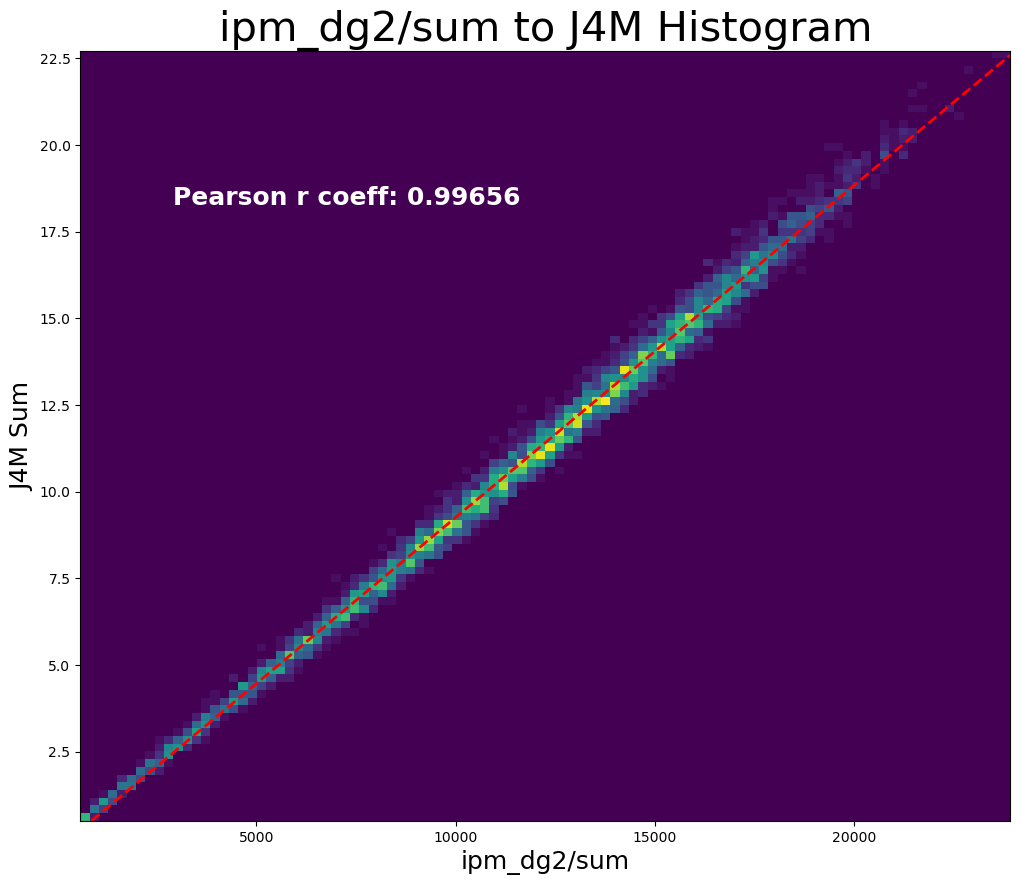

In [18]:
Sum, Xpos, Ypos, Peaks = recalculateDG2IPM(dg2Good[:,8:]);

plt.figure(figsize=[12,10])

poly_coeffs = np.polyfit(Sum, J4MSum, 1)
print(poly_coeffs)
# Generate fit curve
x_fit = np.linspace(np.min(Sum), np.max(Sum), 100)
y_fit = np.polyval(poly_coeffs, x_fit)

# Overlay the fit curve
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear Fit (Low Intensity)', linestyle='--')
#plt.legend()

rcoeff = scipy.stats.pearsonr(Sum, J4MSum)
plt.text(0.1, 0.8, f'Pearson r coeff: {rcoeff.statistic:.5f}',
         fontsize=18, fontweight='bold', transform=plt.gca().transAxes, ha='left', color='White')


plt.hist2d(Sum,J4MSum,100);
plt.title("ipm_dg2/sum to J4M Histogram",fontsize=30)
plt.ylabel("J4M Sum",fontsize=18)
plt.xlabel('ipm_dg2/sum',fontsize=18)
plt.show();

In [6]:
plt.figure(figsize=[20,11])
for i in range(dg2PeakVals.shape[1]):
    plt.subplot(2,4,i+1)
    plt.hist2d(ipmpeaksGood[:,i+8],J4MSum,100,range=[[0,12500],[0,0.7e7]]);
    plt.xlabel(f"BLD Peak {i+8}")
    plt.ylabel("J4M Sum")
    plt.title('IPM to J4M Histogram')
    # plt.ylim(0,3e7)
    # plt.xlim(0,35000)
plt.show();

NameError: name 'dg2PeakVals' is not defined

<Figure size 2000x1100 with 0 Axes>

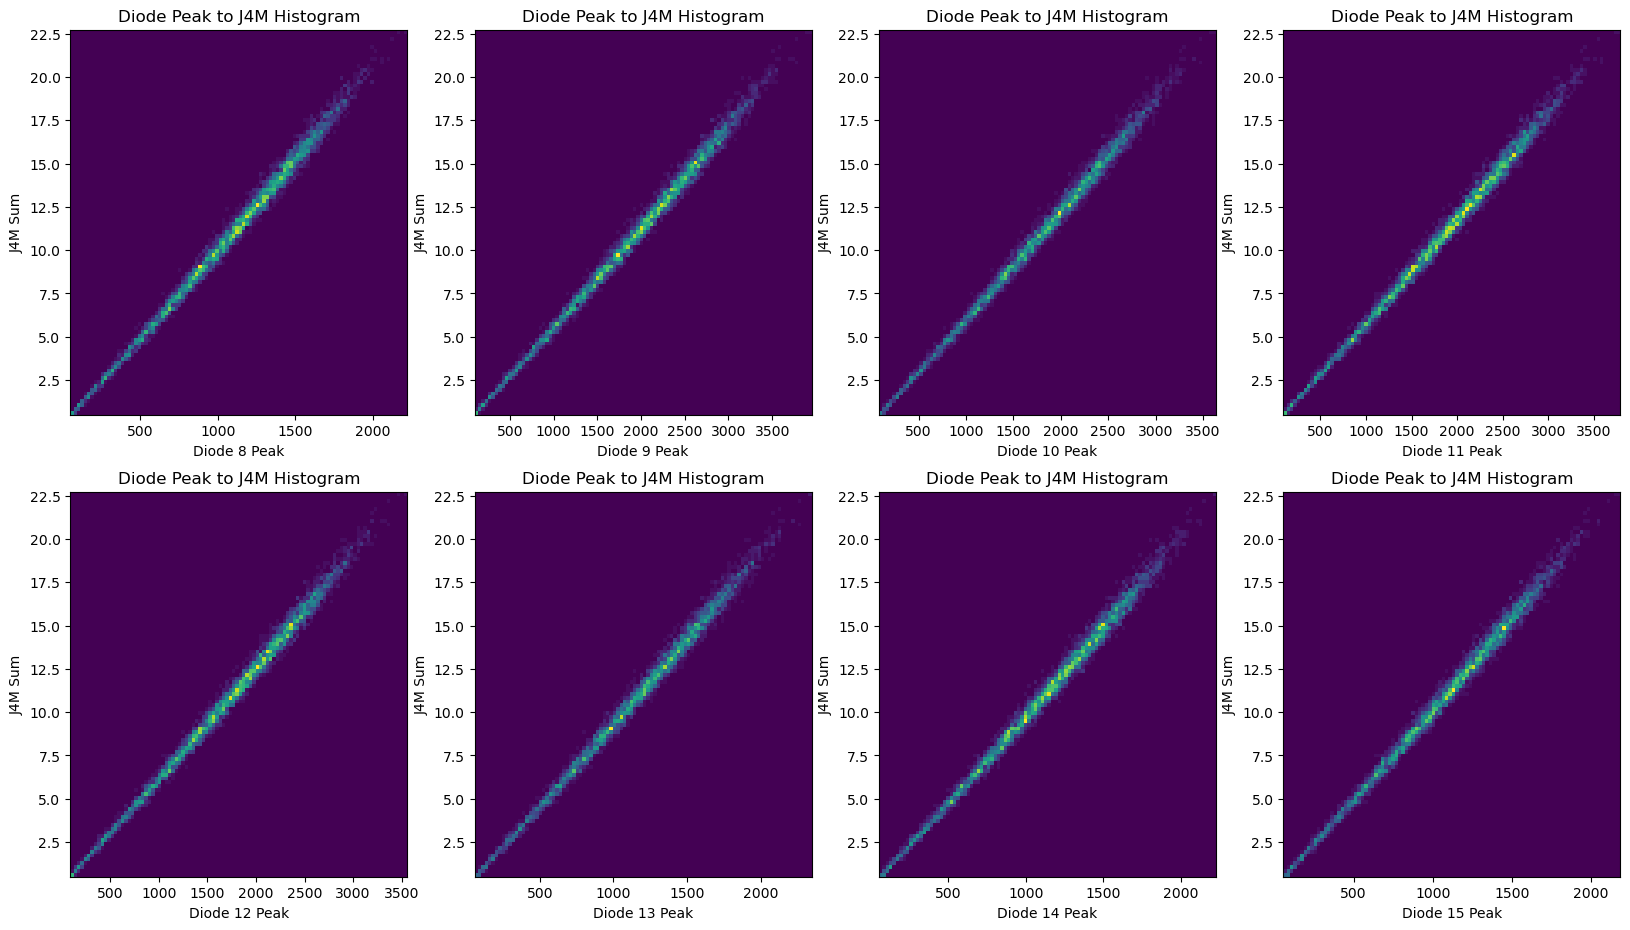

In [20]:
plt.figure(figsize=[20,11])
for i in range(Peaks.shape[1]):
    plt.subplot(2,4,i+1)
    plt.hist2d(Peaks[:,i],J4MSum,100);
    plt.xlabel(f"Diode {i+8} Peak")
    plt.ylabel("J4M Sum")
    plt.title('Diode Peak to J4M Histogram')
plt.show();

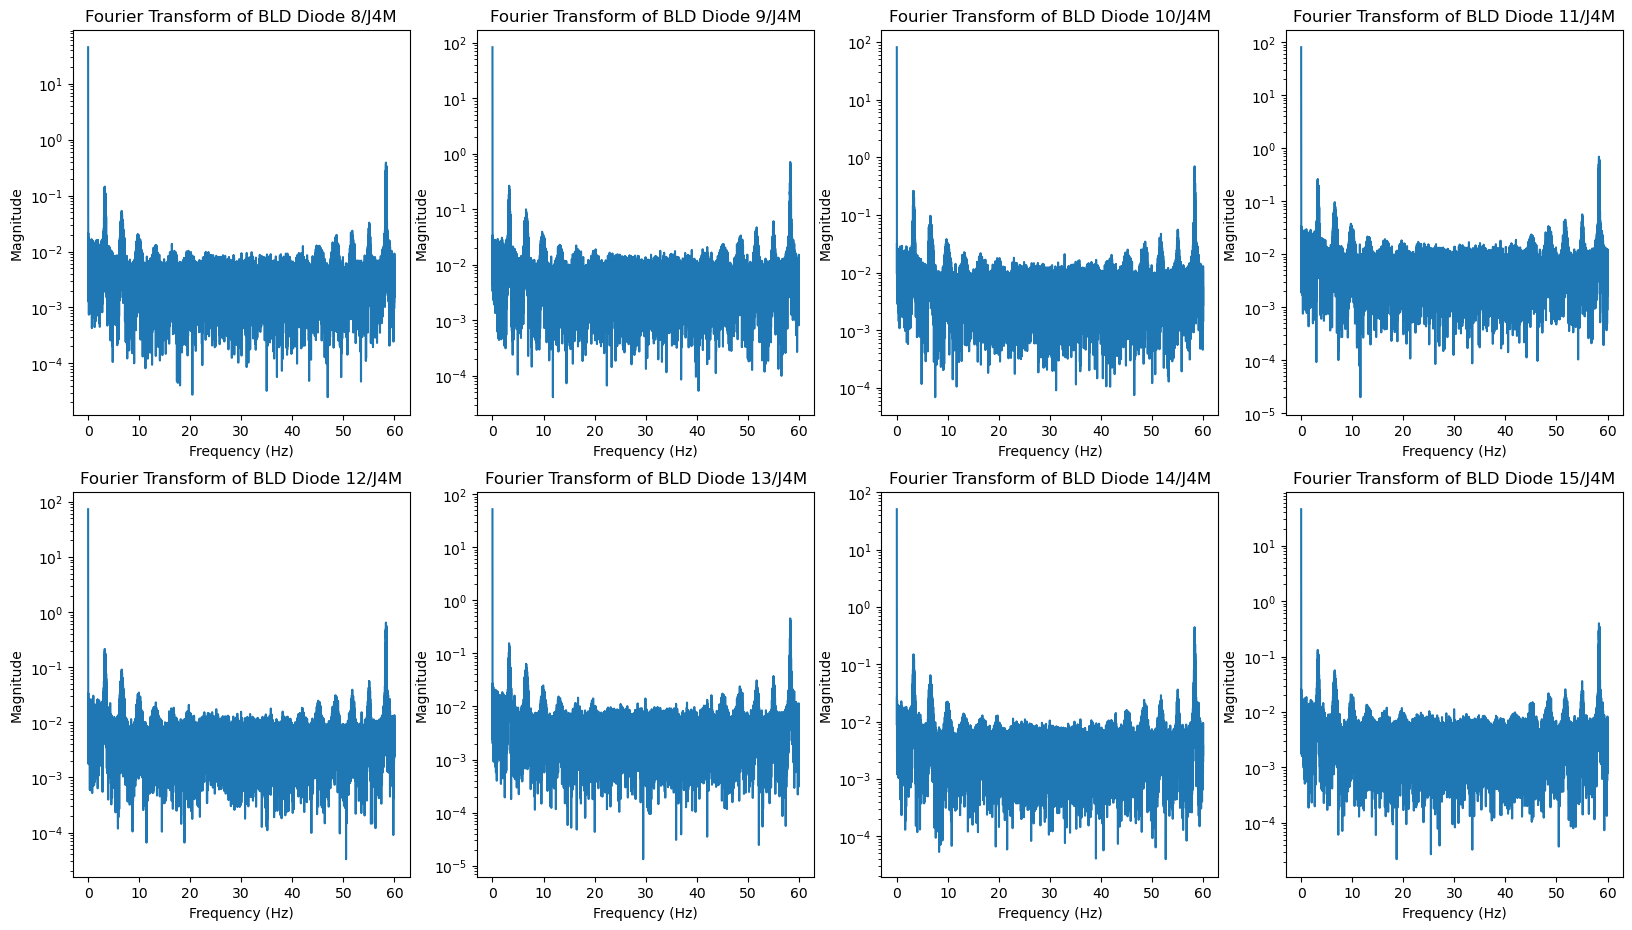

In [157]:
# Sampling rate (120 Hz since each shot is 1/120 sec apart)

fs = 120
plt.figure(figsize=[20,11])
for i in range(dg2PeakVals.shape[1]):
    signal = ipmpeaksGood[:,i+8]/J4MSum
    N = len(signal)  # Number of samples
    # Compute the Fourier Transform
    fft_result = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)  # Scale frequency axis properly
    
    # Plot the magnitude spectrum
    plt.subplot(2,4,i+1)
    plt.plot(freqs[:N//2], np.abs(fft_result[:N//2]))  # Only plot positive frequencies
    plt.yscale('log')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title(f'Fourier Transform of BLD Diode {i+8}/J4M')
plt.show()

Text(0.5, 0, 'Shot Number')

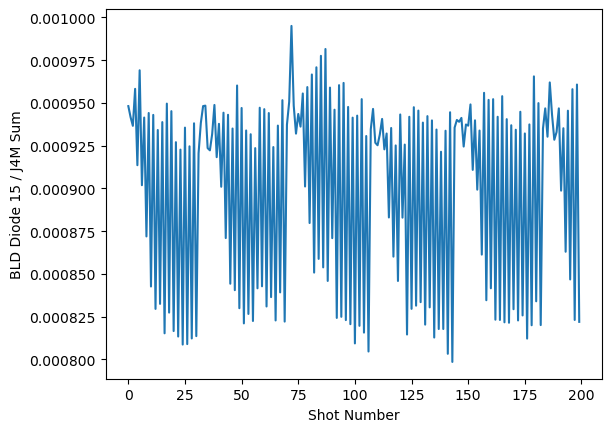

In [161]:
plt.plot(signal[0:200])
plt.ylabel('BLD Diode 15 / J4M Sum')
plt.xlabel('Shot Number')

Text(0, 0.5, 'Shots')

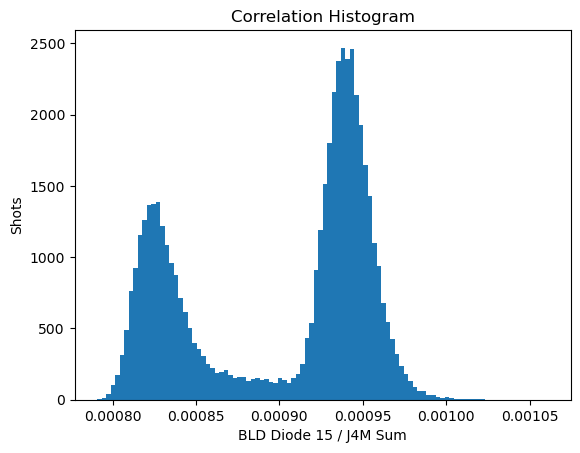

In [162]:
plt.hist(signal,100)
plt.title('Correlation Histogram')
plt.xlabel('BLD Diode 15 / J4M Sum')
plt.ylabel('Shots')

### Attemtping to reconstruct the IPM sum

In [51]:
from scipy import signal
with open('firmfxfast.fir','r') as f:
     b = list(map(float,f))

filtered_trace = -signal.lfilter(b, 1, dg2Good, axis=-1)
    

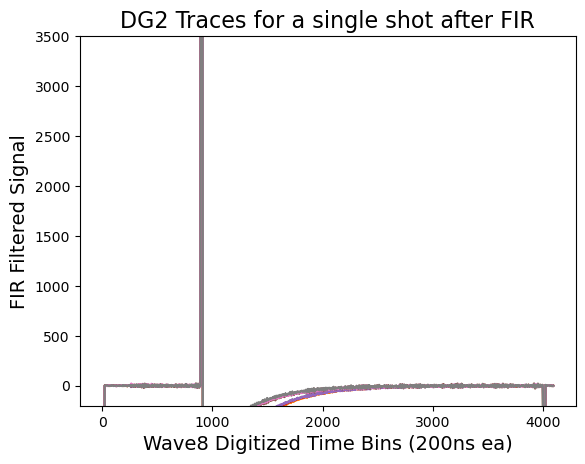

In [52]:
plt.figure()
x = np.arange(4096)
for j in range(filtered_trace.shape[1]):
    plt.plot(x,filtered_trace[0,j])
plt.ylim(-200,3500)
plt.xlabel('Wave8 Digitized Time Bins (200ns ea)',fontsize=14)
plt.ylabel('FIR Filtered Signal',fontsize=14)
plt.title('DG2 Traces for a single shot after FIR', fontsize = 16)
plt.show()

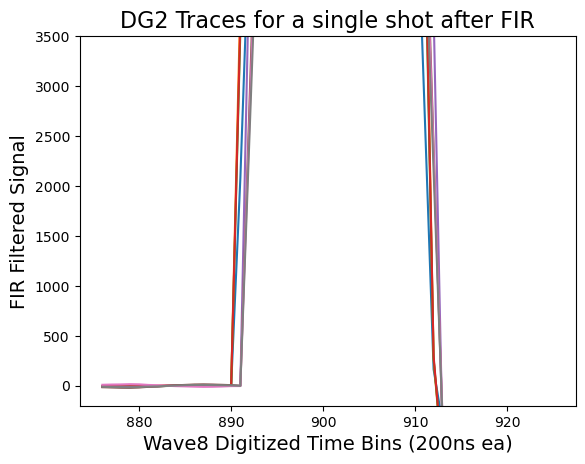

In [53]:
plt.figure()
peak_index = 880
peak_range = 25
shot_no = 0
x = np.arange(4096)
for j in range(filtered_trace.shape[1]):
    plt.plot(x[peak_index-peak_range+21:peak_index+peak_range+21],filtered_trace[shot_no,j,peak_index-peak_range+21:peak_index+peak_range+21])
plt.ylim(-200,3500)
plt.xlabel('Wave8 Digitized Time Bins (200ns ea)',fontsize=14)
plt.ylabel('FIR Filtered Signal',fontsize=14)
plt.title('DG2 Traces for a single shot after FIR', fontsize = 16)
plt.show()

In [54]:
peak_index = 880
peak_range = 25
pk = np.zeros((filtered_trace.shape[0],filtered_trace.shape[1]))
for i in range(filtered_trace.shape[0]):
    for j in range(filtered_trace.shape[1]):
        for k in range(peak_index-peak_range+21,peak_index+peak_range+21): #0 to 112 is if range is 50 with peak index 62
            if pk[i,j] < abs(filtered_trace[i,j,k]):
                pk[i,j] = abs(filtered_trace[i,j,k]) #value

[ 1.04113719e+02 -1.70320541e+05]


Text(0, 0.5, 'J4M Sum')

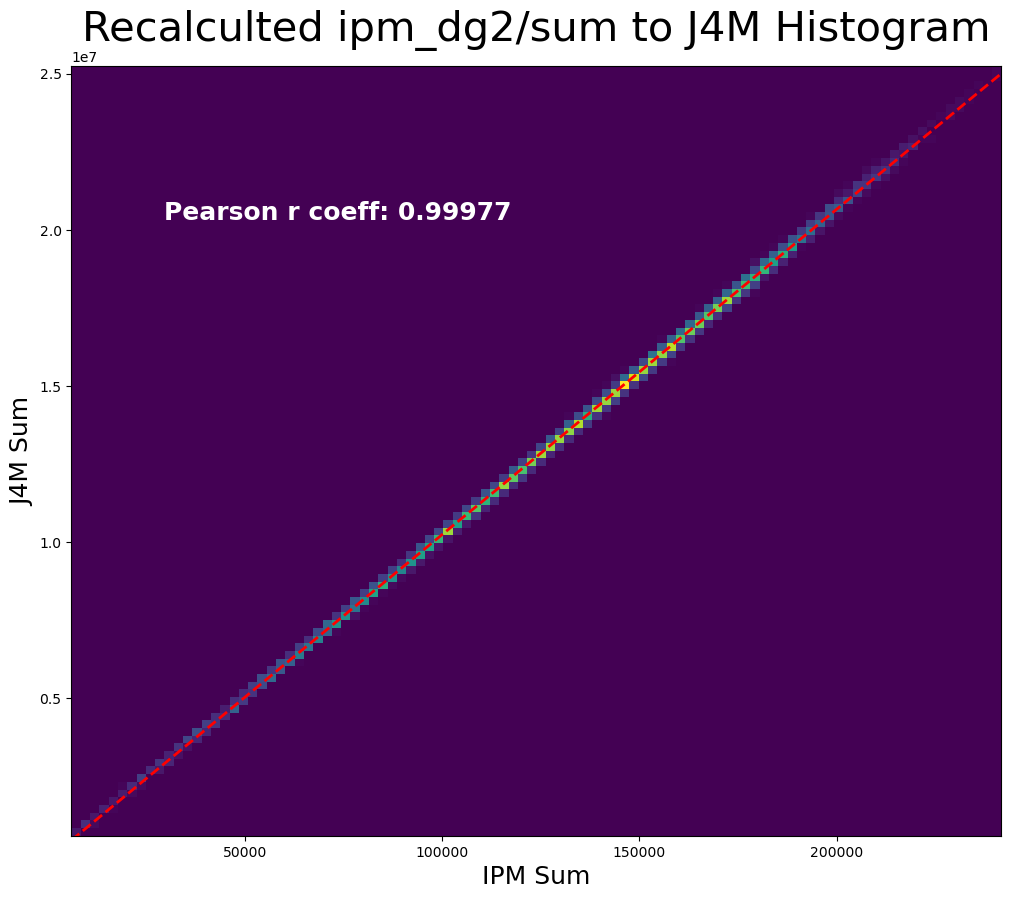

In [88]:
filt = (J4MSum/pk.sum(axis=1) > 80)
pkrecalc = pk.sum(axis=1)[filt]
J4MSumF = J4MSum[filt]

plt.figure(figsize=[12,10])
# Perform polynomial fit of order 2
poly_coeffs = np.polyfit(pkrecalc, J4MSumF, 1)
print(poly_coeffs)

# Generate fit curve
x_fit = np.linspace(np.min(pkrecalc), np.max(pkrecalc), 100)
y_fit = np.polyval(poly_coeffs, x_fit)

# Overlay the fit curve
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear Fit (Low Intensity)', linestyle='--')
#plt.legend()

rcoeff = scipy.stats.pearsonr(pkrecalc, J4MSumF)
plt.text(0.1, 0.8, f'Pearson r coeff: {rcoeff.statistic:.5f}',
         fontsize=18, fontweight='bold', transform=plt.gca().transAxes, ha='left', color='White')


plt.hist2d(pkrecalc,J4MSumF,bins=100);
plt.title('Recalculted ipm_dg2/sum to J4M Histogram',fontsize=30)
plt.xlabel('IPM Sum',fontsize=18)
plt.ylabel('J4M Sum',fontsize=18)



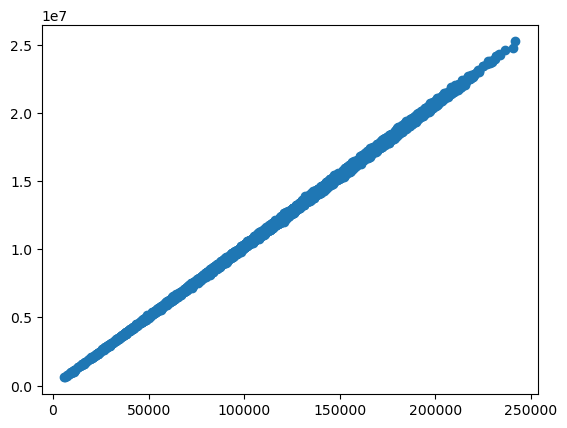

In [84]:
plt.scatter(pkrecalc,J4MSumF)

5.614689096919172

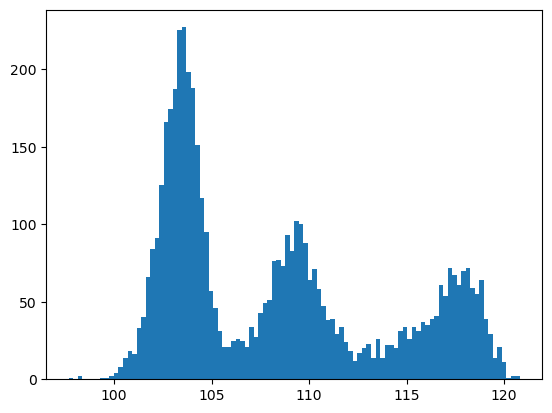

In [87]:
plt.hist(J4MSum/ipmGood,bins=100);
np.std(J4MSum/ipmGood)

1.00399137340168

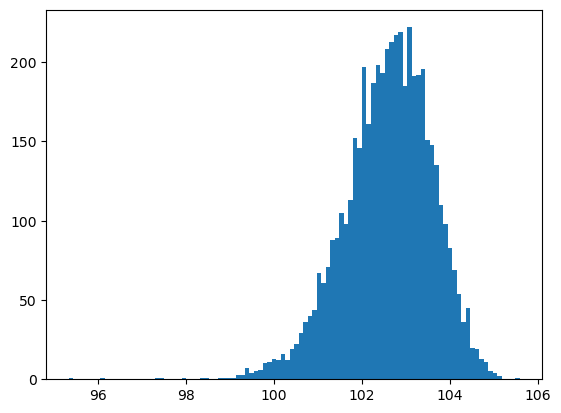

In [86]:

plt.hist(J4MSumF/pkrecalc,bins=100);
np.std(J4MSumF/pkrecalc)

### Adjusting the raw dg2 traces for baseline correction and flipping them

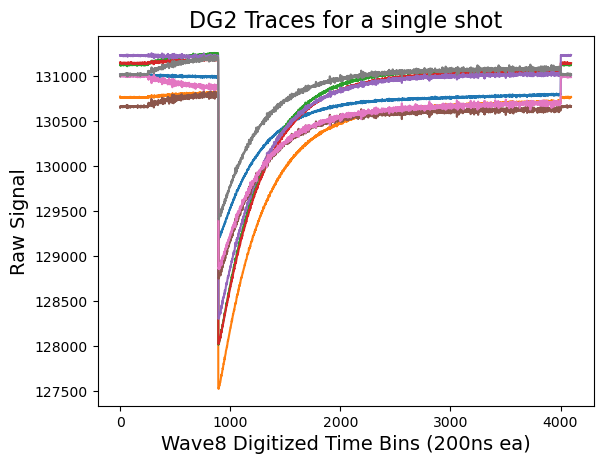

In [20]:
plt.figure()
for j in range(dg2Good.shape[1]):
    plt.plot(dg2Good[0,j,:])
plt.xlabel('Wave8 Digitized Time Bins (200ns ea)',fontsize=14)
plt.ylabel('Raw Signal',fontsize=14)
plt.title('DG2 Traces for a single shot',fontsize=16)
plt.show()

In [68]:
# Correcting the baseline and flipping the curves for each of them
baselineCutoff = 200  # High bound of baseline calculation
baselines = dg2Good[:, :, :baselineCutoff].mean(axis=-1, keepdims=True)# Compute baselines: Take the mean of the first 750 points along axis=-1
dg2CorrectedTrace = (dg2Good - baselines) * -1  # Compute corrected traces in a single step
dg2PeakVals = dg2CorrectedTrace.max(axis=-1) # Compute peak values along the last axis

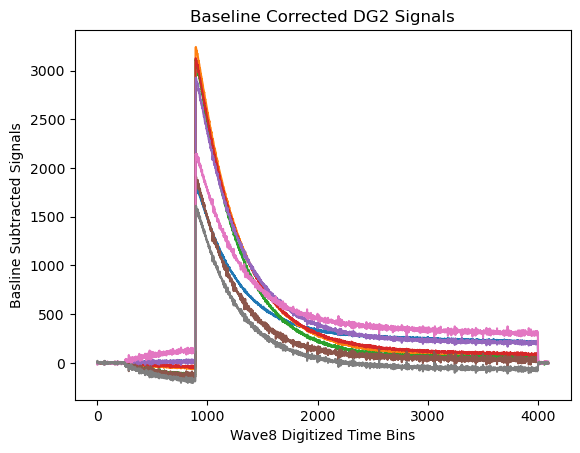

In [145]:
plt.figure()
for j in range(dg2CorrectedTrace.shape[1]):
    plt.plot(dg2CorrectedTrace[0,j,:])
plt.xlabel('Wave8 Digitized Time Bins')
plt.ylabel('Basline Subtracted Signals')
plt.title('Baseline Corrected DG2 Signals')
plt.show()

## Calculating positions based on vals

Text(0.5, 1.0, 'Recorded Position')

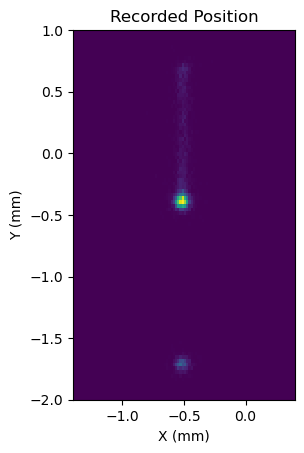

In [67]:
plt.hist2d(xposGood,yposGood,bins=100,range=[[-1.4,0.4],[-2,1]]);
plt.axis('image')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Recorded Position')

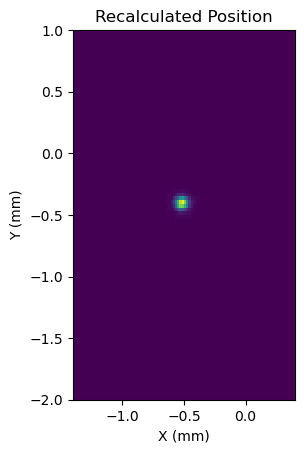

In [68]:
Cx = -4.79
Cy = -5.12
x1 = (100*(pk[:,1]-pk[:,3])/(pk[:,1]+pk[:,3]))/Cx
y1 = (100*(pk[:,2]-pk[:,4])/(pk[:,2]+pk[:,4]))/Cy
# x1 = (100*(dg2PeakVals[:,1]-dg2PeakVals[:,3])/(dg2PeakVals[:,1]+dg2PeakVals[:,3]))/Cx
# y1 = (100*(dg2PeakVals[:,2]-dg2PeakVals[:,4])/(dg2PeakVals[:,2]+dg2PeakVals[:,4]))/Cy
plt.hist2d(x1,y1,bins=100,range=[[-1.4,0.4],[-2,1]]);
plt.axis('image')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Recalculated Position');

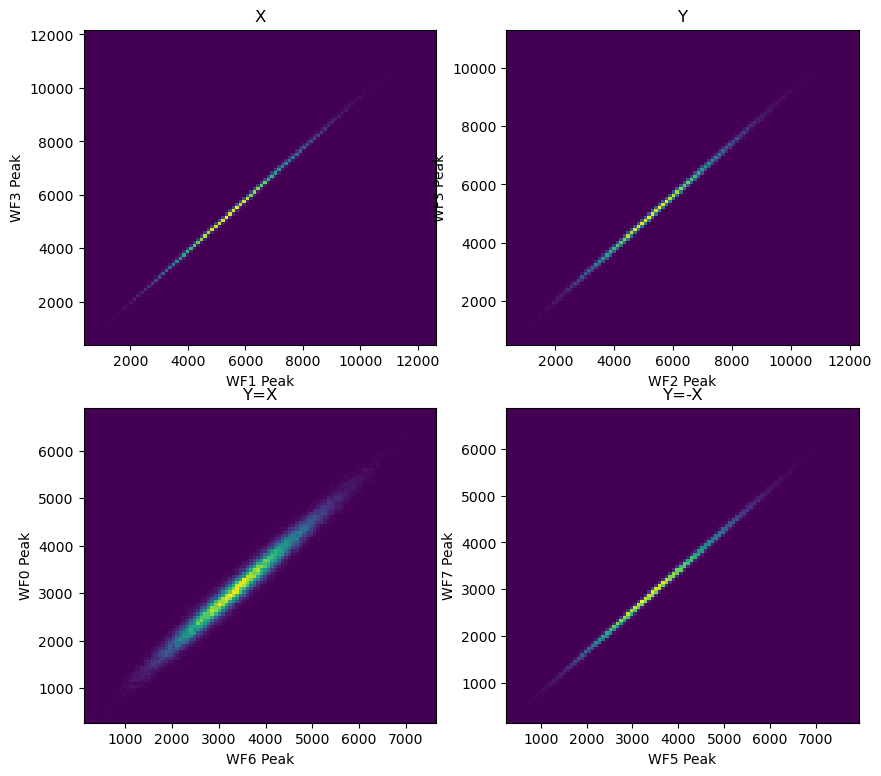

In [147]:
plt.figure(figsize=[10,9])
plt.subplot(2,2,1)
plt.hist2d(dg2PeakVals[:,1],dg2PeakVals[:,3],bins=100); # x
plt.title('X')
plt.xlabel('WF1 Peak')
plt.ylabel('WF3 Peak')
plt.subplot(2,2,2)
plt.hist2d(dg2PeakVals[:,2],dg2PeakVals[:,4],bins=100); # y
plt.title('Y')
plt.xlabel('WF2 Peak')
plt.ylabel('WF3 Peak')
plt.subplot(2,2,3)
plt.hist2d(dg2PeakVals[:,6],dg2PeakVals[:,0],bins=100); # y=x
plt.title('Y=X')
plt.xlabel('WF6 Peak')
plt.ylabel('WF0 Peak')
plt.subplot(2,2,4)
plt.hist2d(dg2PeakVals[:,5],dg2PeakVals[:,7],bins=100); # y=-x
plt.title('Y=-X')
plt.xlabel('WF5 Peak')
plt.ylabel('WF7 Peak');

Text(0.5, 1.0, 'Max of Basline Corrected signals summed vs J4M')

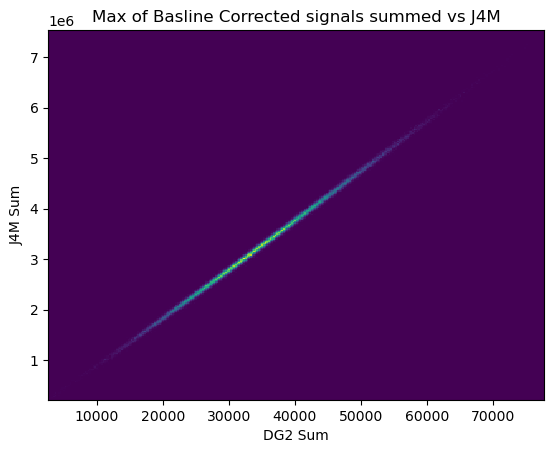

In [69]:
dg2PeakSum = dg2PeakVals.sum(axis=1)
plt.hist2d(dg2PeakSum,J4MSum,bins=300);
plt.xlabel('DG2 Sum')
plt.ylabel('J4M Sum')
plt.title('Max of Basline Corrected signals summed vs J4M')

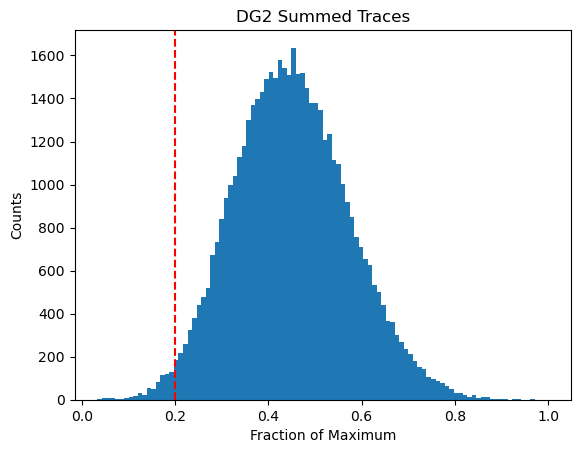

In [149]:
#####
dg2Low = 0.2
#####
plt.hist(dg2PeakSum/dg2PeakSum.max(),bins=100)
plt.axvline(dg2Low,color='r',linestyle='--')
plt.title('DG2 Summed Traces')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()
plt.show()

dg2LowIdx = ((dg2PeakSum/dg2PeakSum.max())<dg2Low) # Creating the mask

In [69]:
fit_x = dg2PeakSum[dg2LowIdx]
fit_y = J4MSum[dg2LowIdx]

# Perform polynomial fit of order 2
poly_coeffs = np.polyfit(fit_x, fit_y, 1)
print(poly_coeffs)

# Compute the predicted values based on the polynomial fit
fitted_values = np.polyval(poly_coeffs, dg2PeakSum)

# Compute residuals
residuals = J4MSum - fitted_values

plt.figure(figsize=[15, 5])
plt.subplot(1, 2, 1)
plt.hist2d(dg2PeakSum, J4MSum, bins=100)
plt.title('DG2 Correlation')
plt.xlabel('DG2 Peak Sum')
plt.ylabel('J4M Sum')

# Generate fit curve
x_fit = np.linspace(np.min(dg2PeakSum), np.max(dg2PeakSum), 100)
y_fit = np.polyval(poly_coeffs, x_fit)

# Overlay the fit curve
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear Fit (Low Intensity)', linestyle='--')
plt.legend()

rcoeff = scipy.stats.pearsonr(dg2PeakSum, J4MSum)
plt.text(0.1, 0.8, f'Pearson r coeff: {rcoeff.statistic:.5f}',
         fontsize=12, fontweight='bold', transform=plt.gca().transAxes, ha='left', color='White')

# Plot the residual histogram in the second subplot
plt.subplot(1, 2, 2)
hist, xedges, yedges, img = plt.hist2d(dg2PeakSum, residuals, bins=100, cmap='viridis')
plt.axhline(0, linestyle='--', color='r')
plt.title('DG2 Correlation - Linear Fit')
plt.xlabel('DG2 Peak Sum')
plt.ylabel('Residuals (J4M Sum - Quadratic Fit)')
plt.show()

NameError: name 'dg2PeakSum' is not defined